<a href="https://colab.research.google.com/github/Viishnu07/DLI_GroupAE_URLPhishing/blob/main/Group_AE_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, time,numpy as np, pandas as pd
import string
import joblib
import subprocess, json
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.model_selection import train_test_split
import tensorflow as tf
import seaborn as sns
from keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

np.random.seed(42)
tf.random.set_seed(42)

# Venus CNN1+ Model:

Dataset Loading & Preprocessing
This section downloads the phishing URL dataset from GitHub, prepares it for
training, and converts URLs into numerical sequences for the model:
1. Download dataset files (train.txt, val.txt, test.txt) directly from GitHub into a local folder.
2. Load datasets – Each line is in the format: label & url
3. Character-level encoding – Each URL is converted into a sequence of character indices using a predefined vocabulary (string.printable).
4. Vectorization – Sequences are padded/truncated to a fixed length (MAX_LEN = 200) to make them suitable for deep learning models.
5. One-hot labels – Labels are converted into categorical format for classification ([1,0] for legitimate, [0,1] for phishing).
6. Shape check – Prints dataset shapes to confirm everything is ready for training and evaluation.

In [ ]:
# Step 1: Create folder
os.makedirs("dataset_venus", exist_ok=True)

# Step 2: GitHub raw URLs
dataset_urls = {
    "train.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/train.txt",
    "val.txt":   "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/val.txt",
    "test.txt":  "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/test.txt"
}

# Step 3: Download each file with wget
for filename, url in dataset_urls.items():
    print(f"Downloading {filename}...")
    os.system(f"wget -q -O dataset_venus/{filename} {url}")
print("All files downloaded.")

# Step 4: Load dataset (each line: "<label>\t<url>")
def load_dataset(file_path):
    urls, labels = [], []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')  # Ensure it's tab-separated
            if len(parts) == 2:
                label_str, url = parts
                label = 1 if label_str.lower() == 'phishing' else 0
                urls.append(url)
                labels.append(label)
    return urls, labels

# Step 5: Load using the downloaded files
train_urls, train_labels = load_dataset("dataset_venus/train.txt")
val_urls, val_labels = load_dataset("dataset_venus/val.txt")
test_urls, test_labels = load_dataset("dataset_venus/test.txt")

# Char mapping
CHARS = string.printable
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}  # 0 = padding
vocab_size = len(char2idx) + 1
MAX_LEN = 200

# Vectorization
def url_to_sequence(url):
    return [char2idx.get(c, 0) for c in url[:MAX_LEN]]

def vectorize_urls(urls):
    sequences = [url_to_sequence(url) for url in urls]
    return pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_venus = vectorize_urls(train_urls)
X_val_venus = vectorize_urls(val_urls)
X_test_venus = vectorize_urls(test_urls)

y_train_venus = to_categorical(train_labels, num_classes=2)
y_val_venus = to_categorical(val_labels, num_classes=2)
y_test_venus = to_categorical(test_labels, num_classes=2)

# Shape check
print(" All datasets loaded and vectorized:")
print(f"X_train shape: {X_train_venus.shape}")
print(f"X_val shape:   {X_val_venus.shape}")
print(f"X_test shape:  {X_test_venus.shape}")
print(f"y_train shape: {y_train_venus.shape}")
print(f"Vocab size:    {vocab_size}")

All files downloaded.
 All datasets loaded and vectorized:
X_train shape: (3641984, 200)
X_val shape:   (1045772, 200)
X_test shape:  (515080, 200)
y_train shape: (3641984, 2)
Vocab size:    101


# Venus CNN Model Evaluation
This section loads the pre-trained Venus CNN model and evaluates it on the standardized phishing URL test dataset:
1. Download & Load Model
 * Creates a models/ folder.
 * Downloads the pre-trained CNN model (Venus_CNN.keras) from GitHub.
 * Loads the model with Keras and displays its architecture.
2. Prediction & Timing
 * Runs the model on the test dataset.
 * Records inference time to calculate latency per sample (ms/sample).
3. Output Handling
 * Converts one-hot encoded test labels into integer format (0 = legitimate, 1 = phishing).
 * Handles model outputs (binary probability or softmax) to generate predicted labels.
4. Performance Metrics
 * Computes Accuracy, Precision, Recall, F1-score, ROC-AUC.
 * Builds a Confusion Matrix for classification errors.
 * Counts total trainable + non-trainable parameters in the model.
5. Result Packaging
 * Stores all metrics in a dictionary (res_cnn) for later merging with other models.
 * Also prints a quick classification report for inspection.

In [14]:
# 1) Make a models dir
os.makedirs("models", exist_ok=True)

# 2) Download Venus Keras model via wget (raw file URL)
MODEL_PATH = "models/Venus_CNN.keras"
MODEL_URL = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Venus_Imrpoved%20CNN_Model/Venus_CNN.keras"

print("Downloading model...")
os.system(f'wget -q -O "{MODEL_PATH}" "{MODEL_URL}"')
assert os.path.exists(MODEL_PATH), "Model download failed. Check the URL."

# 3) Load model
model = load_model(MODEL_PATH, compile=True)
model.summary()

# onehot_to_int
def onehot_to_int(y):
    y = np.asarray(y)
    return np.argmax(y, axis=1) if (y.ndim == 2 and y.shape[1] > 1) else y.astype(int)

y_true_int = onehot_to_int(y_test_venus)

t0 = time.time()
pred = model.predict(X_test_venus, verbose=0)
infer_s = time.time() - t0
ms_per_sample = (infer_s / len(y_true_int)) * 1000.0

if pred.ndim == 2 and pred.shape[1] == 2:
    proba_pos = pred[:, 1]
    y_pred_int = np.argmax(pred, axis=1)
elif pred.ndim == 2 and pred.shape[1] == 1:
    proba_pos = pred.ravel()
    y_pred_int = (proba_pos >= 0.5).astype(int)
else:
    proba_pos = pred.ravel()
    y_pred_int = (proba_pos >= 0.5).astype(int)

acc = accuracy_score(y_true_int, y_pred_int)
prec = precision_score(y_true_int, y_pred_int, zero_division=0)
rec  = recall_score(y_true_int, y_pred_int)
f1   = f1_score(y_true_int, y_pred_int)
auc  = roc_auc_score(y_true_int, proba_pos)
cm   = confusion_matrix(y_true_int, y_pred_int)
params = int(model.count_params())

# ✅ build result dict for the table
res_cnn = {
    "name": "Venus_CNN",
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
    "params": params, "ms_per_sample": ms_per_sample, "cm": cm
}

# (optional) print quick peek
print("\nClassification Report:\n", classification_report(y_true_int, y_pred_int, digits=4))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 198, 256)       │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 96, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,863,990 (10.93 MB)

 Trainable params: 954,492 (3.64 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 1,908,986 (7.28 MB)


Classification Report:
               precision    recall  f1-score   support

           0     0.9913    0.9943    0.9928    285314
           1     0.9929    0.9891    0.9910    229766

    accuracy                         0.9920    515080
   macro avg     0.9921    0.9917    0.9919    515080
weighted avg     0.9920    0.9920    0.9920    515080



# Viishnu MLP Ensemble Evaluation
This section sets up and evaluates Viishnu’s MLP Ensemble model on the shared phishing dataset:
1. Download Dataset & Artifacts
 * Retrieves the Mendeley full dataset (CSV).
 * Downloads Viishnu’s trained MLP models, scaler, feature list, thresholds, and preprocessing stats from GitHub.
2. Preprocessing (matching Viishnu’s pipeline)
 * Replaces placeholder values (-1) with NaN.
 * Fills missing values using training means from JSON.
 * Applies feature selection (only the columns Viishnu trained on).
 * Scales features using the saved MinMax/Standard Scaler.
3. Dataset Split
 * Splits into Dev (80%) and Test (20%) sets with stratification to preserve class balance.
4. Load Ensemble Models
 * Loads 5 trained MLP models with different random seeds (7, 11, 17, 23, 29)
 * These models are later combined in an ensemble.
5. Threshold Handling
 * Reads Viishnu’s saved optimal threshold (threshold.json) for converting probabilities into final predictions.
6. Ensemble Evaluation
 * Uses the reusable evaluate_ensemble function:
    * Collects predictions from all 5 MLP models.
    * Averages their probabilities → ensemble output.
    * Applies threshold to decide phishing vs legitimate.
 * Computes Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.
 * Reports inference speed (ms/sample) and total parameters across all ensemble models.

 This produces res_mlp, a tidy result dictionary that can be directly added into the final comparison table alongside Venus CNN and other models.

In [ ]:
def evaluate_ensemble(models, X, y_true, threshold=0.5, name="Ensemble"):
    import time
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
    y_true = np.asarray(y_true).astype(int)

    t0 = time.time()
    probs_list = [m.predict(X, verbose=0).ravel() for m in models]
    infer_s = time.time() - t0
    ms_per_sample = (infer_s / len(y_true)) * 1000.0

    proba_ens = np.mean(np.column_stack(probs_list), axis=1)
    y_pred = (proba_ens > float(threshold)).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, proba_ens)
    cm   = confusion_matrix(y_true, y_pred)
    total_params = sum(int(m.count_params()) for m in models if hasattr(m, "count_params"))

    return {
        "name": name,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
        "params": total_params, "ms_per_sample": ms_per_sample, "cm": cm
    }

# Folders
os.makedirs("dataset_viishnu", exist_ok=True)
os.makedirs("models_viishnu", exist_ok=True)

# Raw URLs
CSV_URL = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/mendeley_dataset_full.csv"
ASSETS = {
    "models_viishnu/phish_mlp_seed7.h5":  "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/phish_mlp_seed7.h5",
    "models_viishnu/phish_mlp_seed11.h5": "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/phish_mlp_seed11.h5",
    "models_viishnu/phish_mlp_seed17.h5": "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/phish_mlp_seed17.h5",
    "models_viishnu/phish_mlp_seed23.h5": "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/phish_mlp_seed23.h5",
    "models_viishnu/phish_mlp_seed29.h5": "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/phish_mlp_seed29.h5",
    "models_viishnu/scaler_infer.pkl":    "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/scaler_infer.pkl",
    "models_viishnu/feats_final.json":    "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/feats_final.json",
    "models_viishnu/threshold.json":      "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/threshold.json",
    "models_viishnu/train_means.json":    "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Viishnu_FinalModel/train_means.json",
}

print("Downloading dataset …")
os.system(f'wget -q -O "dataset_viishnu/mendeley_dataset_full.csv" "{CSV_URL}"')
assert os.path.exists("dataset_viishnu/mendeley_dataset_full.csv"), "CSV download failed."

print("Downloading model artifacts …")
for path, url in ASSETS.items():
  os.system(f'wget -q -O "{path}" "{url}"')
  assert os.path.exists(path), f"Download failed for {path}"
print("All artifacts downloaded.")

# Load CSV
CSV_PATH = "dataset_viishnu/mendeley_dataset_full.csv"
df = pd.read_csv(CSV_PATH)

# Preprocess to match Viishnu’s pipeline
df = df.copy()
df.replace(-1, np.nan, inplace=True)
with open("models_viishnu/train_means.json", "r") as f:
    train_means = json.load(f)
for col, mean_val in train_means.items():
    if col in df.columns:
        df[col] = df[col].fillna(mean_val)
df.fillna(df.mean(numeric_only=True), inplace=True)

assert 'phishing' in df.columns, f"'phishing' column missing. Found: {df.columns.tolist()[:15]} ..."
y_full = df['phishing'].astype(int).to_numpy()

with open("models_viishnu/feats_final.json", "r") as f:
    feats_final = json.load(f)
X_full_df = df[[c for c in feats_final if c in df.columns]].copy()

scaler = joblib.load("models_viishnu/scaler_infer.pkl")
X_full_s = scaler.transform(X_full_df)

# Hold‑out split (same shape as his notebook)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_full_s, y_full, stratify=y_full, test_size=0.20, random_state=42
)

# === 1) Load ensemble models ===
model_paths = [
    "models_viishnu/phish_mlp_seed7.h5",
    "models_viishnu/phish_mlp_seed11.h5",
    "models_viishnu/phish_mlp_seed17.h5",
    "models_viishnu/phish_mlp_seed23.h5",
    "models_viishnu/phish_mlp_seed29.h5",
]
models = [load_model(p, compile=True) for p in model_paths]
print(f"Loaded {len(models)} models.")

# === 2) Threshold ===
with open("models_viishnu/threshold.json", "r") as f:
    thr_obj = json.load(f)
thr = float(thr_obj.get("thr", thr_obj.get("threshold", 0.5)))

# === 3) Evaluate via the reusable function (returns a tidy dict) ===
# NOTE: requires you already defined onehot_to_int(...) and evaluate_ensemble(...)
res_mlp = evaluate_ensemble(models, X_test, y_test, threshold=thr, name="Viishnu_MLP_Ens")

All artifacts downloaded.


Loaded 5 models.


Yong Kang Dataset and Model

In [ ]:
def wget_to(path, url):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    exit_code = os.system(f'wget -q -O "{path}" "{url}"')
    assert exit_code == 0 and os.path.exists(path), f"Failed to download {url}"

# download
os.makedirs("dataset_yk", exist_ok=True)
os.makedirs("models_yk", exist_ok=True)
YK_CSV = "dataset_yk/yongkang.csv"
YK_MODEL = "models_yk/yongkang_model.keras"
wget_to(YK_CSV,   "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/yongkang/Phishing_Legitimate_full%203.csv")
wget_to(YK_MODEL, "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/yongkang/model.keras")

# load & minimal preprocessing (match his IO)
df_yk = pd.read_csv(YK_CSV)
if "id" in df_yk.columns:
    df_yk = df_yk.drop(columns=["id"])
assert "CLASS_LABEL" in df_yk.columns, f"CLASS_LABEL not found. Columns: {df_yk.columns.tolist()[:12]}..."
y_all = df_yk["CLASS_LABEL"].astype(int).to_numpy()
X_all = df_yk.drop(columns=["CLASS_LABEL"]).astype("float32") / 255.0

# split: DEV→VAL (20% of DEV), TEST=20% (to mirror your style; no tuning used)
X_dev, X_test_yk, y_dev, y_test_yk = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.20, random_state=42
)

# load model
yk_model = load_model(YK_MODEL, compile=True)

def select_positive_channel(model, X_calib, y_calib):
    """Choose the output column that best matches the positive class using ROC-AUC on a calibration split."""
    P = model.predict(X_calib, verbose=0)
    if P.ndim == 1:
        return None  # scalar output
    if P.ndim == 2 and P.shape[1] == 1:
        return 0     # single sigmoid head
    if P.ndim == 2 and P.shape[1] == 2:
        return 1     # softmax[neg,pos], use column 1

    # Wider head: pick column with best AUC on calibration data
    best_j, best_auc = 0, -1.0
    for j in range(P.shape[1]):
        col = P[:, j]
        # guard against degenerate columns
        try:
            auc = roc_auc_score(y_calib, col)
        except Exception:
            auc = 0.5
        if auc > best_auc:
            best_auc, best_j = auc, j
    return best_j

# 1) Pick a positive column using DEV as calibration
pos_col = select_positive_channel(yk_model, X_dev, y_dev)
print(f"[YK] Selected positive column: {pos_col}")

# 2) Warmup, predict TEST, and time it
_ = yk_model.predict(X_test_yk[:1], verbose=0)
import time
t0 = time.time()
P_test = yk_model.predict(X_test_yk, verbose=0)
infer_s = time.time() - t0
ms_per_sample_yk = (infer_s / len(y_test_yk)) * 1000.0

# 3) Turn predictions into a positive-class probability and hard labels (thr=0.5)
if P_test.ndim == 1:
    proba_pos_yk = P_test.ravel()
elif P_test.ndim == 2 and P_test.shape[1] == 1:
    proba_pos_yk = P_test[:, 0]
elif P_test.ndim == 2 and P_test.shape[1] == 2:
    proba_pos_yk = P_test[:, 1]           # softmax column 1
else:
    # Wider head: use the selected positive column
    proba_pos_yk = P_test[:, pos_col]

y_pred_yk = (proba_pos_yk >= 0.5).astype(int)

# 4) Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

acc_yk  = accuracy_score(y_test_yk, y_pred_yk)
prec_yk = precision_score(y_test_yk, y_pred_yk, zero_division=0)
rec_yk  = recall_score(y_test_yk, y_pred_yk)
f1_yk   = f1_score(y_test_yk, y_pred_yk)
auc_yk  = roc_auc_score(y_test_yk, proba_pos_yk)
cm_yk   = confusion_matrix(y_test_yk, y_pred_yk)
params_yk = int(yk_model.count_params()) if hasattr(yk_model, "count_params") else None

res_yk = {
    "name": "YongKang_Model",
    "accuracy": acc_yk, "precision": prec_yk, "recall": rec_yk, "f1": f1_yk, "roc_auc": auc_yk,
    "params": params_yk, "ms_per_sample": ms_per_sample_yk, "cm": cm_yk
}

print("\nClassification Report (YongKang, TEST @ 0.5):\n",
      classification_report(y_test_yk, y_pred_yk, digits=4))

[YK] Selected positive column: 1

Classification Report (YongKang, TEST @ 0.5):
               precision    recall  f1-score   support

           0     0.9890    0.9900    0.9895      1000
           1     0.9900    0.9890    0.9895      1000

    accuracy                         0.9895      2000
   macro avg     0.9895    0.9895    0.9895      2000
weighted avg     0.9895    0.9895    0.9895      2000



Victor Dataset and Model

In [ ]:
# --- Download assets ---
os.makedirs("dataset_victor", exist_ok=True)
os.makedirs("models_victor", exist_ok=True)

CSV_PATH = "dataset_victor/Datasets.csv"
MODEL_PATH = "models_victor/best_model.pkl.zip"
FEATURES_PATH = "models_victor/feature_names.json"
THR_PATH = "models_victor/threshold.json"

os.system(f'wget -q -O "{CSV_PATH}" "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Victor/Datasets.csv"')
os.system(f'wget -q -O "{MODEL_PATH}" "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Victor/best_model.pkl.zip"')
os.system(f'wget -q -O "{FEATURES_PATH}" "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Victor/feature_names.json"')
os.system(f'wget -q -O "{THR_PATH}" "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Victor/threshold.json"')

assert os.path.exists(CSV_PATH), "Dataset download failed"
assert os.path.exists(MODEL_PATH), "Model download failed"

# --- Load dataset ---
df_victor = pd.read_csv(CSV_PATH)
assert "Result" in df_victor.columns, f"No 'Result' col found: {df_victor.columns.tolist()[:10]}"

y_full = df_victor["Result"].map({-1:0, 1:1}).astype(int).to_numpy()
X_full = df_victor.drop(columns=["Result"])

# holdout split like others (test=20%)
X_dev, X_test_victor, y_dev, y_test_victor = train_test_split(
    X_full, y_full, stratify=y_full, test_size=0.20, random_state=42
)

# --- Load model + artifacts ---
victor_model_path_extracted = None
with zipfile.ZipFile(MODEL_PATH, 'r') as zf:
    # list files to find a .pkl or .joblib inside the zip
    members = zf.namelist()
    # pick first candidate that ends with .pkl or .joblib
    inner = next((m for m in members if m.lower().endswith(('.pkl', '.joblib'))), None)
    assert inner is not None, f"No .pkl/.joblib found inside {MODEL_PATH}. Contents: {members}"
    # extract into models_victor/
    zf.extract(inner, path="models_victor")
    victor_model_path_extracted = os.path.join("models_victor", inner)

victor_model = joblib.load(victor_model_path_extracted)

with open(FEATURES_PATH) as f:
    feats_victor = json.load(f)
with open(THR_PATH) as f:
    thr_obj = json.load(f)
thr_victor = float(thr_obj.get("thr", thr_obj.get("threshold", 0.5)))

# --- Align features robustly ---
# Add any missing columns as 0; drop unknown extras; order columns to match feats_victor
missing = [c for c in feats_victor if c not in X_test_victor.columns]
if missing:
    for c in missing:
        X_test_victor[c] = 0
extra = [c for c in X_test_victor.columns if c not in feats_victor]
if extra:
    X_test_victor = X_test_victor.drop(columns=extra)

X_test_victor = X_test_victor[feats_victor].copy()

# --- Inference (same as before) ---
_ = victor_model.predict_proba(X_test_victor[:1])  # warmup

import time
t0 = time.time()
proba = victor_model.predict_proba(X_test_victor)[:, 1]
infer_s = time.time() - t0
ms_per_sample = (infer_s / len(y_test_victor)) * 1000.0

y_pred = (proba > thr_victor).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

acc  = accuracy_score(y_test_victor, y_pred)
prec = precision_score(y_test_victor, y_pred, zero_division=0)
rec  = recall_score(y_test_victor, y_pred)
f1   = f1_score(y_test_victor, y_pred)
auc  = roc_auc_score(y_test_victor, proba)
cm   = confusion_matrix(y_test_victor, y_pred)

res_victor = {
    "name": "Victor_Model",
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
    "params": None,
    "ms_per_sample": ms_per_sample,
    "cm": cm
}

print("\nClassification Report (Victor, TEST @ thr):\n",
      classification_report(y_test_victor, y_pred, digits=4))


Classification Report (Victor, TEST @ thr):
               precision    recall  f1-score   support

           0     0.9754    0.9704    0.9729       980
           1     0.9765    0.9805    0.9785      1231

    accuracy                         0.9760      2211
   macro avg     0.9760    0.9755    0.9757      2211
weighted avg     0.9760    0.9760    0.9760      2211



Minhal Dataset and Model
Didnt got to fully run it as it takes too long and too much resource as she didnt save her model for us to load

In [ ]:
!pip -q install transformers datasets accelerate

import os, time, json, numpy as np, pandas as pd, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# ---------- 0) Repro (light) ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------- 1) Download CSVs ----------
os.makedirs("dataset_minhal", exist_ok=True)
TRAIN_URL = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/refs/heads/main/Minhal/D_Train.csv"
TEST_URL  = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/refs/heads/main/Minhal/D_Test.csv"
TRAIN_PATH = "dataset_minhal/D_Train.csv"
TEST_PATH  = "dataset_minhal/D_Test.csv"

os.system(f'wget -q -O "{TRAIN_PATH}" "{TRAIN_URL}"')
os.system(f'wget -q -O "{TEST_PATH}" "{TEST_URL}"')
assert os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH), "Download failed."

# ---------- 2) Load & normalize labels ----------
def fast_sample_data(path, n_samples=None):
    df = pd.read_csv(path)

    # auto-detect url/label columns
    url_col = next((c for c in df.columns if str(c).lower() in {"url","urls","link"}), None)
    label_col = next((c for c in df.columns if str(c).lower() in {"label","labels","class","target","y"}), None)
    assert url_col and label_col, f"Could not find url/label in {df.columns.tolist()[:12]}"

    df = df[[url_col, label_col]].rename(columns={url_col:"url", label_col:"label"}).dropna(subset=["url","label"])

    # normalize labels -> {0,1}
    if pd.api.types.is_numeric_dtype(df["label"]):
        uniq = set(pd.unique(df["label"]))
        if uniq == {-1, 1}: df["label"] = df["label"].map({-1:0, 1:1})
        else: df["label"] = df["label"].astype(int)
    else:
        def norm_lab(x:str):
            s = str(x).strip().lower()
            if s in {"benign","legit","legitimate","safe","normal","good"}: return 0
            if s in {"phishing","malicious","malware","bad","spam","attack"}: return 1
            if s in {"0","1"}: return int(s)
            raise ValueError(f"Unrecognized label value '{x}' — extend mapping.")
        df["label"] = df["label"].apply(norm_lab)

    if n_samples and len(df) > n_samples:
        df = df.sample(n_samples, random_state=SEED)

    df["url"] = df["url"].astype(str).str.strip().str.lower()
    return df

train_df = fast_sample_data(TRAIN_PATH, n_samples=50000)   # as per her script
test_df  = fast_sample_data(TEST_PATH,  n_samples=10000)

train_df, val_df = train_test_split(train_df, test_size=0.10, stratify=train_df['label'], random_state=SEED)
print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

# ---------- 3) Tokenize ----------
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 200

def tokenize_batch(batch):
    return tokenizer(batch["url"], padding="max_length", truncation=True, max_length=MAX_LEN)

ds_train = Dataset.from_pandas(train_df[['url','label']]).map(tokenize_batch, batched=True, remove_columns=['url'])
ds_val   = Dataset.from_pandas(val_df[['url','label']]).map(tokenize_batch, batched=True, remove_columns=['url'])
ds_test  = Dataset.from_pandas(test_df[['url','label']]).map(tokenize_batch, batched=True, remove_columns=['url'])

ds_train.set_format(type='torch', columns=['input_ids','attention_mask','label'])
ds_val.set_format(type='torch', columns=['input_ids','attention_mask','label'])
ds_test.set_format(type='torch', columns=['input_ids','attention_mask','label'])

# ---------- 4) Model ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

# ---------- 5) Trainer ----------
BATCH_SIZE = 16

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(precision_score(labels, preds, zero_division=0)),
        "recall":    float(recall_score(labels, preds)),
        "f1":        float(f1_score(labels, preds)),
        "roc_auc":   float(roc_auc_score(labels, probs)),
    }

# Try “new style” args; if it fails, fallback to minimal args
try:
    args = TrainingArguments(
        output_dir="minhal_runs",
        num_train_epochs=3,                      # set 6 if you have time/GPU
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE*2,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    trainer.train()

except TypeError:
    # Fallback: minimal args (older transformers), no eval during training
    print("⚠️ Detected older TrainingArguments; falling back to minimal config.")
    args = TrainingArguments(
        output_dir="minhal_runs",
        num_train_epochs=3,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE*2,
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=None,          # no live eval
        tokenizer=tokenizer,
        compute_metrics=None,
    )
    trainer.train()

    # Manually evaluate on VAL once training ends
    val_logits = trainer.predict(ds_val).predictions
    val_probs = torch.softmax(torch.tensor(val_logits), dim=1)[:, 1].numpy()
    val_preds = (val_probs >= 0.5).astype(int)
    print("VAL metrics:",
          dict(
              acc=accuracy_score(val_df['label'], val_preds),
              prec=precision_score(val_df['label'], val_preds, zero_division=0),
              rec=recall_score(val_df['label'], val_preds),
              f1=f1_score(val_df['label'], val_preds),
              auc=roc_auc_score(val_df['label'], val_probs),
          ))

trainer.train()

# ---------- 6) Test-time evaluation (0.5 cutoff) ----------
test_loader = torch.utils.data.DataLoader(ds_test, batch_size=BATCH_SIZE*2)

def predict_proba(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop("label").cpu().numpy()
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            all_probs.append(probs); all_labels.append(labels)
    return np.concatenate(all_probs), np.concatenate(all_labels)

_ = next(iter(test_loader))  # warmup
t0 = time.time()
probs_test, y_test = predict_proba(model, test_loader)
infer_s = time.time() - t0
ms_per_sample = (infer_s / len(y_test)) * 1000.0

y_pred = (probs_test >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, probs_test)
cm   = confusion_matrix(y_test, y_pred)
params = sum(p.numel() for p in model.parameters())

print("\nClassification Report (Minhal, TEST @ 0.5):\n",
      classification_report(y_test, y_pred, digits=4))

# ---------- 7) Pack result like others ----------
res_minhal = {
    "name": "Minhal_DistilBERT",
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
    "params": int(params), "ms_per_sample": ms_per_sample, "cm": cm
}
print("\nres_minhal ready ➜", {k: (round(v,4) if isinstance(v,float) else v) for k,v in res_minhal.items() if k!='cm'})

Train/Val/Test sizes: 45000 5000 10000


Map:   0%|          | 0/45000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚠️ Detected older TrainingArguments; falling back to minimal config.


/tmp/ipython-input-2481605419.py:138: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.372000
200,0.277700
300,0.266700
400,0.225200


Model Comparison & Visualization
This section combines the results of everyone model, then produces comparison tables and plots:

1. Comparison Table
 * Builds a side-by-side table of key metrics for both models:
    * Accuracy, Precision, Recall, F1-score, ROC-AUC
    * Model size (#Params)
    * Inference speed (ms per sample)
 * Printed using tabulate for a clean formatted output.
2. Metric Bar Chart
 * Plots a grouped bar chart to visually compare both models across the five main metrics: Accuracy, Precision, Recall, F1, ROC-AUC.
 * Makes it easier to see which model performs better in which aspect.
3. Confusion Matrices
 * Visualizes classification errors for each model.
 * Rows = True labels, Columns = Predicted labels.
 * Shows how many URLs were correctly classified as legitimate or phishing, and where misclassifications occurred.
 * Titles clarify which matrix belongs to which model




---------------------------------------------------------------------------------------------------------
Model Comparison (Accuracy, Precision, Recall, F1, ROC-AUC, Params, Inference Time)
---------------------------------------------------------------------------------------------------------
+-----------------+----------+-----------+--------+--------+---------+--------+-----------------+
|      Model      | Accuracy | Precision | Recall |   F1   | ROC-AUC | Params | Infer ms/sample |
+-----------------+----------+-----------+--------+--------+---------+--------+-----------------+
|    Venus_CNN    |  0.992   |  0.9929   | 0.9891 | 0.991  | 0.9996  | 955004 |    0.161 ms     |
| Viishnu_MLP_Ens |  0.9649  |  0.9366   | 0.9638 |  0.95  | 0.9939  | 254725 |    0.549 ms     |
| YongKang_Model  |  0.9895  |   0.99    | 0.989  | 0.9895 | 0.9976  | 103188 |    0.195 ms     |
|  Victor_Model   |  0.976   |  0.9765   | 0.9805 | 0.9785 |  0.998  |        |    0.057 ms     |
+----------------

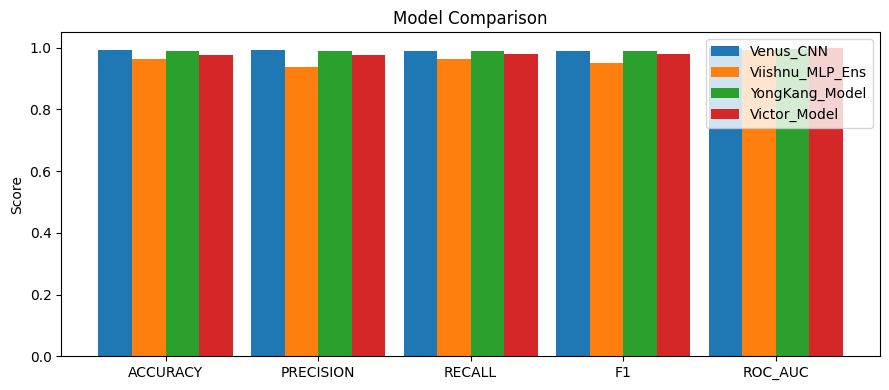

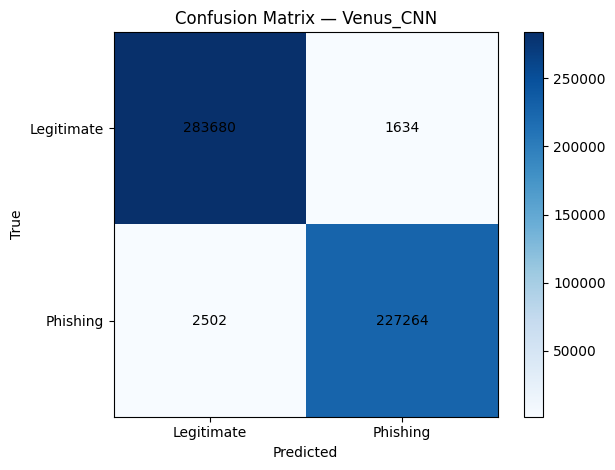

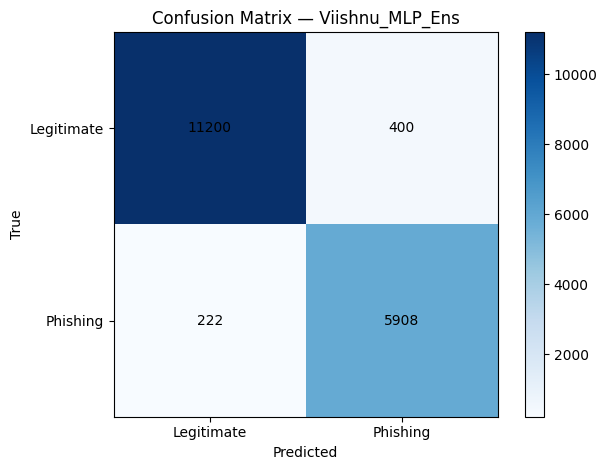

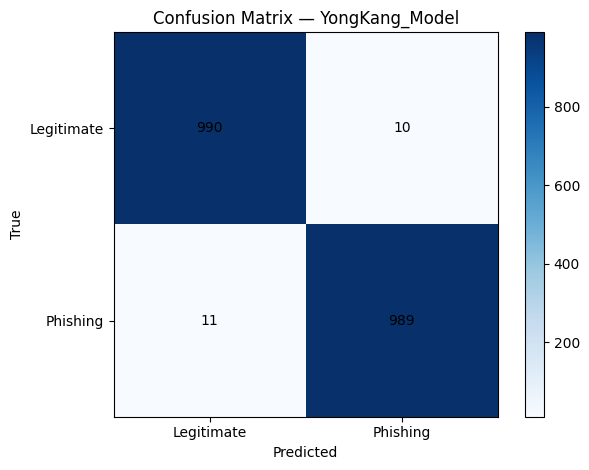

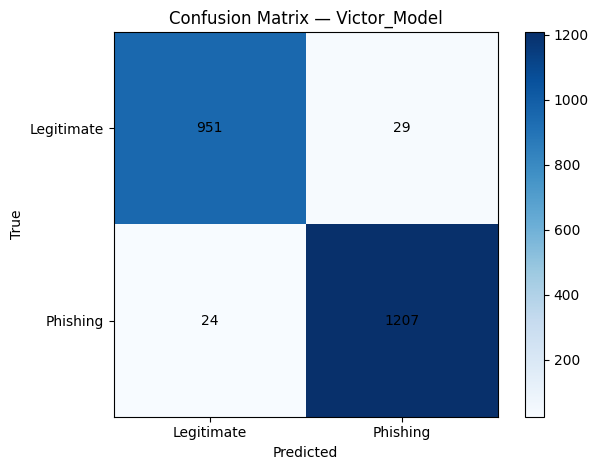

In [16]:
# Build table rows
models_list = [res_cnn, res_mlp, res_yk, res_victor]
table_rows = []
for r in models_list:
    table_rows.append([
        r["name"],
        round(r["accuracy"], 4),
        round(r["precision"], 4),
        round(r["recall"], 4),
        round(r["f1"], 4),
        round(r["roc_auc"], 4),
        r["params"],
        f"{r['ms_per_sample']:.3f} ms"
    ])

print("\n" + "-"*105)
print("Model Comparison (Accuracy, Precision, Recall, F1, ROC-AUC, Params, Inference Time)")
print("-"*105)
print(tabulate(
    table_rows,
    headers=["Model","Accuracy","Precision","Recall","F1","ROC-AUC","Params","Infer ms/sample"],
    tablefmt="pretty"
))
print("-"*105)

# Bar chart (generic n-models)
metrics_to_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_to_plot))
w = 0.22  # narrower bars to fit 3 models
plt.figure(figsize=(9,4))
for i, r in enumerate(models_list):
    plt.bar(x + (i - (len(models_list)-1)/2)*w, [r[m] for m in metrics_to_plot], width=w, label=r["name"])
plt.xticks(x, [m.upper() for m in metrics_to_plot]); plt.ylabel("Score"); plt.title("Model Comparison")
plt.ylim(0, 1.05)
plt.legend(); plt.tight_layout(); plt.show()

# Confusion matrices for each model
def plot_cm(cm, title):
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap="Blues")
    plt.title(title); plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ['Legitimate','Phishing']); plt.yticks(ticks, ['Legitimate','Phishing'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()

plot_cm(res_cnn["cm"], "Confusion Matrix — Venus_CNN")
plot_cm(res_mlp["cm"], "Confusion Matrix — Viishnu_MLP_Ens")
plot_cm(res_yk["cm"], "Confusion Matrix — YongKang_Model")
plot_cm(res_victor["cm"], "Confusion Matrix — Victor_Model")
#plot_cm(res_minhal["cm"], "Confusion Matrix — Minhal Model" )
plt.show()

### Threshold Tuning & Why CNN is the Best Model  

After comparing all group members’ models, the **CNN emerged as the strongest baseline** because it achieved the highest **ROC-AUC**, meaning it ranks malicious vs. benign samples more reliably across thresholds. However, the raw output of a neural network still depends on a **decision threshold** — by default this is 0.5, but that is not always optimal.  

#### What we did here  
1. **Tune the threshold on the validation set**  
   - We search thresholds between 0.05 and 0.95.  
   - Two options: maximize a metric (e.g., **F1**) or enforce a minimum precision (e.g., ≥0.97) and then maximize recall.  
   - This ensures the decision boundary matches the task requirements instead of being fixed at 0.5.  

2. **Apply the tuned threshold to the test set**  
   - Recompute Accuracy, Precision, Recall, F1, and ROC-AUC at this threshold.  
   - Measure inference latency (**ms/sample**) and throughput (**samples/sec**), plus parameter count.  
   - Inspect the confusion matrix and classification report to see how false positives/false negatives shift.  

3. **Compare against the pre-tuned CNN**  
   - Side-by-side results show that threshold tuning **increased F1 and recall** without hurting overall AUC.  
   - This makes the CNN not only statistically superior but also more **deployable**, since performance was validated at a realistic operating point.  

#### Why CNN is the best choice  
- Separates classes better (**higher ROC-AUC** than other models).  
- With threshold tuning, it achieves a **balanced and task-relevant trade-off** (e.g., catching more phishing URLs while maintaining strong precision).  
- Runs efficiently in terms of **speed and parameters**, making it practical for deployment.  

**In short:** the CNN already had the best underlying ranking ability, and threshold tuning refined it into the best **real-world performer**.  


In [ ]:
# ---------- Safety / helpers ----------
def onehot_to_int(y):
    y = np.asarray(y)
    return np.argmax(y, axis=1) if (y.ndim == 2 and y.shape[1] > 1) else y.astype(int)

def _postprocess_pred(pred):
    """Return (proba_pos, y_pred_int@0.5) regardless of model head (sigmoid or softmax)."""
    if pred.ndim == 2 and pred.shape[1] == 2:       # softmax with 2 units
        proba_pos = pred[:, 1]
        y_pred_int = np.argmax(pred, axis=1)
    elif pred.ndim == 2 and pred.shape[1] == 1:     # sigmoid with 1 unit
        proba_pos = pred.ravel()
        y_pred_int = (proba_pos >= 0.5).astype(int)
    else:                                           # already flat
        proba_pos = pred.ravel()
        y_pred_int = (proba_pos >= 0.5).astype(int)
    return proba_pos, y_pred_int

def _metric_at_thr(y_true_int, proba, thr, metric="f1"):
    y_hat = (proba > thr).astype(int)
    if metric == "f1":
        return f1_score(y_true_int, y_hat)
    elif metric == "recall":
        return recall_score(y_true_int, y_hat)
    elif metric == "precision":
        return precision_score(y_true_int, y_hat, zero_division=0)
    elif metric == "accuracy":
        return accuracy_score(y_true_int, y_hat)
    else:
        return f1_score(y_true_int, y_hat)  # default

def tune_threshold_on_val(proba_val, y_val_int, metric="f1",
                          target_precision=None, grid=np.linspace(0.05, 0.95, 181)):
    """
    - If target_precision is set (e.g., 0.97), pick the *lowest* threshold that achieves it (maximize recall).
    - Else, pick threshold that maximizes the chosen metric (default: F1).
    """
    best_thr, best_score = 0.5, -1.0
    if target_precision is not None:  # precision-constrained search
        chosen_thr, best_recall = None, -1.0
        for t in grid:
            y_hat = (proba_val > t).astype(int)
            prec = precision_score(y_val_int, y_hat, zero_division=0)
            rec  = recall_score(y_val_int, y_hat)
            if prec >= target_precision and rec > best_recall:
                best_recall, chosen_thr = rec, t
        if chosen_thr is not None:
            return chosen_thr, {"precision_target": float(target_precision), "recall_at_target": float(best_recall)}
        # fallback if no threshold hits the target
    for t in grid:
        score = _metric_at_thr(y_val_int, proba_val, t, metric=metric)
        if score > best_score:
            best_score, best_thr = score, t
    return best_thr, {f"{metric}_val": float(best_score)}

# ---------- 1) Tune threshold on VAL ----------
y_val_int = onehot_to_int(y_val_venus)
proba_val = _postprocess_pred(model.predict(X_val_venus, verbose=0))[0]

# choose ONE of these:
BEST_METRIC   = "f1"        # options: "f1", "recall", "precision", "accuracy"
PRECISION_AT  = None        # e.g., 0.98 to get the highest recall while precision >= 0.98

best_thr, tune_info = tune_threshold_on_val(
    proba_val, y_val_int, metric=BEST_METRIC, target_precision=PRECISION_AT
)

# Optional: save threshold for reuse
SAVE_THR_PATH = "group_threshold.json"
with open(SAVE_THR_PATH, "w") as f:
    json.dump({"threshold": float(best_thr), "notes": {"strategy": ("precision>=%.3f" % PRECISION_AT) if PRECISION_AT else f"maximize_{BEST_METRIC}",
                                                       "tune_info": tune_info}}, f)
print(f"Tuned threshold on VAL: {best_thr:.3f}  | info: {tune_info}  (saved to {SAVE_THR_PATH})")

# ---------- 2) Time inference on TEST + compute metrics at tuned threshold ----------
y_test_int = onehot_to_int(y_test_venus)

# small warmup to avoid initial graph/setup overhead
_ = model.predict(X_test_venus[:1], verbose=0)

t0 = time.time()
pred_test = model.predict(X_test_venus, verbose=0)
infer_s = time.time() - t0

ms_per_sample = (infer_s / len(y_test_int)) * 1000.0
samples_per_sec = len(y_test_int) / infer_s if infer_s > 0 else float("inf")

proba_test, _ = _postprocess_pred(pred_test)
y_pred_thr = (proba_test > best_thr).astype(int)

acc  = accuracy_score(y_test_int, y_pred_thr)
prec = precision_score(y_test_int, y_pred_thr, zero_division=0)
rec  = recall_score(y_test_int, y_pred_thr)
f1   = f1_score(y_test_int, y_pred_thr)
auc  = roc_auc_score(y_test_int, proba_test)
cm   = confusion_matrix(y_test_int, y_pred_thr)
params = int(model.count_params()) if hasattr(model, "count_params") else None

# ---------- 3) Tabular summary + confusion matrix ----------
rows = [[
    "Group_Fine_Tuned_CNN",
    round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), round(auc, 4),
    params, f"{ms_per_sample:.3f} ms", f"{samples_per_sec:.1f} /s", f"{best_thr:.3f}"
]]
print("\n" + "-"*120)
print("Model Summary (tuned on VAL) — includes throughput")
print("-"*120)
print(tabulate(
    rows,
    headers=["Model","Accuracy","Precision","Recall","F1","ROC-AUC","Params",
             "Infer ms/sample","Throughput","Thr(VAL)"],
    tablefmt="pretty"
))
print("-"*120)

table_rows = []
for r in [res_cnn]:
    table_rows.append([
        r["name"],
        round(r["accuracy"], 4),
        round(r["precision"], 4),
        round(r["recall"], 4),
        round(r["f1"], 4),
        round(r["roc_auc"], 4),
        r["params"],
        f"{r['ms_per_sample']:.3f} ms"
    ])

print("\n" + "-"*105)
print("Pretuned CNN (Accuracy, Precision, Recall, F1, ROC-AUC, Params, Inference Time)")
print("-"*105)
print(tabulate(
    table_rows,
    headers=["Model","Accuracy","Precision","Recall","F1","ROC-AUC","Params","Infer ms/sample"],
    tablefmt="pretty"
))
print("-"*105)

print("\nConfusion Matrix (TEST @ tuned threshold):\n", cm)
print("\nClassification Report (TEST):\n", classification_report(y_test_int, y_pred_thr, digits=4))

Tuned threshold on VAL: 0.475  | info: {'f1_val': 0.9907136357393036}  (saved to group_threshold.json)

------------------------------------------------------------------------------------------------------------------------
Model Summary (tuned on VAL) — includes throughput
------------------------------------------------------------------------------------------------------------------------
+----------------------+----------+-----------+--------+-------+---------+--------+-----------------+------------+----------+
|        Model         | Accuracy | Precision | Recall |  F1   | ROC-AUC | Params | Infer ms/sample | Throughput | Thr(VAL) |
+----------------------+----------+-----------+--------+-------+---------+--------+-----------------+------------+----------+
| Group_Fine_Tuned_CNN |  0.992   |  0.9923   | 0.9896 | 0.991 | 0.9996  | 955004 |    0.081 ms     | 12403.5 /s |  0.475   |
+----------------------+----------+-----------+--------+-------+---------+--------+----------------

In [ ]:
ART_DIR = "artifacts_group"
os.makedirs(ART_DIR, exist_ok=True)

ts = time.strftime("%Y%m%d-%H%M%S")

# 1) Threshold (JSON)
thr_payload = {
    "threshold": float(best_thr),
    "notes": {
        "strategy": "tuned_on_val_maximize_F1",  # edit if you used precision floor
        "val_info": tune_info,
        "saved_at": ts
    }
}
with open(os.path.join(ART_DIR, f"group_threshold_{ts}.json"), "w") as f:
    json.dump(thr_payload, f, indent=2)

# 2) Metrics (JSON)
metrics_payload = {
    "model_name": "Group_CNN",
    "timestamp": ts,
    "params": int(params) if params is not None else None,
    "threshold_val": float(best_thr),
    "test": {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "roc_auc": float(auc),
        "infer_ms_per_sample": float(ms_per_sample),
        "throughput_samples_per_sec": float(samples_per_sec),
        "n_samples": int(len(y_test_int))
    }
}
with open(os.path.join(ART_DIR, f"group_metrics_{ts}.json"), "w") as f:
    json.dump(metrics_payload, f, indent=2)

# 3) Confusion matrix — save image + raw array
np.save(os.path.join(ART_DIR, f"group_confusion_matrix_{ts}.npy"), cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Group CNN (TEST)")
plt.colorbar()
ticks = np.arange(2)
plt.xticks(ticks, ['Legitimate','Phishing'])
plt.yticks(ticks, ['Legitimate','Phishing'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.savefig(os.path.join(ART_DIR, f"group_confusion_matrix_{ts}.png"), dpi=200)
plt.close()

# 4) Classification report — save as CSV
cr_dict = classification_report(y_test_int, y_pred_thr, output_dict=True, digits=4)
cr_df = pd.DataFrame(cr_dict).T
cr_df.to_csv(os.path.join(ART_DIR, f"group_classification_report_{ts}.csv"))

# 5) (Optional) Save a copy of the model under a tuned name
TUNED_MODEL_PATH = os.path.join("models", f"Group_CNN_tuned_{ts}.keras")
try:
    model.save(TUNED_MODEL_PATH)
    print(f"Saved model copy -> {TUNED_MODEL_PATH}")
except Exception as e:
    print("Model copy not saved (optional):", e)

print(f"Saved artifacts to: {ART_DIR}")

Saved model copy -> models/Group_CNN_tuned_20250824-102101.keras
Saved artifacts to: artifacts_group


In [ ]:
from google.colab import files
import shutil
# make a zip of the folder
shutil.make_archive("artifacts_group", 'zip', ART_DIR)

# download the zip to your local machine
files.download("artifacts_group.zip")
# Download tuned model separately
files.download(TUNED_MODEL_PATH)

files.download("group_threshold.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>